In [128]:
import os 
import re
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

from analysis_shared_functions import bulk_vs_singlecell_matrix_viz, all_samples_matrix_viz

In [ ]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "HYSYS"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 100000
rd = 1

# Data munging

## Similarity matrix

In [34]:
if pseudobulk:
    hysys_df = pd.read_csv(
        DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/concordance_output.txt", 
        sep="\t", index_col=0, header=None
    )
else:
    hysys_df = pd.read_csv(
        DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/concordance_output.txt", 
        sep="\t", index_col=0, header=None
    )

In [35]:
hysys_df.head()

,1,2,3
0,,,
low_grade_glioma/pseudobulk/ncells_100000/read_depth_1/GSM7326880_pseudobulk_GSM7326880_ncells_100000_1_individual_variants.snps,low_grade_glioma/pseudobulk/ncells_100000/read...,1.000,1380
low_grade_glioma/pseudobulk/ncells_100000/read_depth_1/GSM7326880_pseudobulk_GSM7326880_ncells_100000_1_individual_variants.snps,low_grade_glioma/pseudobulk/ncells_100000/read...,1.000,1380
low_grade_glioma/pseudobulk/ncells_100000/read_depth_1/GSM7326880_pseudobulk_GSM7326880_ncells_100000_1_individual_variants.snps,low_grade_glioma/pseudobulk/ncells_100000/read...,1.000,1380
low_grade_glioma/pseudobulk/ncells_100000/read_depth_1/GSM7326880_pseudobulk_GSM7326880_ncells_100000_1_individual_variants.snps,low_grade_glioma/pseudobulk/ncells_100000/read...,0.012,3364
low_grade_glioma/pseudobulk/ncells_100000/read_depth_1/GSM7326880_pseudobulk_GSM7326880_ncells_100000_1_individual_variants.snps,low_grade_glioma/pseudobulk/ncells_100000/read...,0.012,3364


In [36]:
if dataset == "hgsoc":
    regex_exp = r"[a-zA-Z0-9]{32}_"
elif dataset == "low_grade_glioma":
    regex_exp = r"^GSM[0-9]{7}_"

hysys_dict = {
    x: 
    re.sub(regex_exp, "", x.replace(f"{dataset}/", "").replace("_individual_variants.snps", "").replace("pseudobulk/", "").replace("real_data/", "").replace(f"ncells_{ncells}/", "").replace(f"read_depth_{rd}/", ""))
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [38]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_1,1.000,1380
pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,1.000,1380
pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_3,1.000,1380
pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_1,0.012,3364
pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,0.012,3364


In [39]:
def long_df_to_matrix_hysys(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values='Concordance',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [40]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [42]:
hysys_matrix.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,1.000,1.000,1.000,0.012,0.012,0.012,0.002,0.002,0.002,0.013,...,0.003,0.003,0.003,0.003,0.002,0.002,0.002,0.001,0.001,0.001
pseudobulk_GSM7326880_ncells_100000_2,1.000,1.000,1.000,0.012,0.012,0.012,0.002,0.002,0.002,0.013,...,0.003,0.003,0.003,0.003,0.002,0.002,0.002,0.001,0.001,0.001
pseudobulk_GSM7326880_ncells_100000_3,1.000,1.000,1.000,0.012,0.012,0.012,0.002,0.002,0.002,0.013,...,0.003,0.003,0.003,0.003,0.002,0.002,0.002,0.001,0.001,0.001
pseudobulk_GSM7326881_ncells_100000_1,0.012,0.012,0.012,1.000,1.000,1.000,0.002,0.004,0.003,0.021,...,0.006,0.004,0.003,0.004,0.006,0.006,0.006,0.001,0.001,0.001
pseudobulk_GSM7326881_ncells_100000_2,0.012,0.012,0.012,1.000,1.000,1.000,0.002,0.004,0.003,0.021,...,0.006,0.004,0.003,0.004,0.006,0.006,0.006,0.001,0.001,0.001


In [43]:
hysys_matrix.shape

(66, 66)

## Sample matches

In [53]:
if pseudobulk:
    sample_match_path = os.path.join(
        DATA_PATH, 
        f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/model_results.txt", 
    )
else:
    sample_match_path = os.path.join(
        DATA_PATH,
        f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/model_results.txt",
    )

In [61]:
def parse_hysys_model_results(file_path):
    """
    Parse HYSYS model_results.txt file to categorize sample relationships.
    
    Args:
        file_path (str): Path to the model_results.txt file
        
    Returns:
        pd.DataFrame: DataFrame with MultiIndex (sample1, sample2) and 'match' column
                     Values: 1 (matching), 0 (not matching), NaN (inconclusive)
    """
    import re
    import pandas as pd
    import itertools
    
    with open(file_path, 'r') as file:
        content = file.read()
    
    # Initialize collections
    matching_pairs = set()
    inconclusive_pairs = set()
    all_samples = set()
    
    # Clean sample names function
    def clean_sample_name(sample_path):
        # Extract filename from path
        sample_name = sample_path.split('/')[-1]
        # Remove file extension
        sample_name = sample_name.replace('.snps', '')
        # Apply same regex cleanup as other tools
        sample_name = re.sub(regex_exp, "", sample_name)
        sample_name = sample_name.replace("_individual_variants", "").replace("ds.", "")
        return sample_name
    
    # Find all "reject concordance value" lines (inconclusive)
    reject_pattern = r"reject concordance value.*?\(([^,]+),\s*([^)]+)\)"
    reject_matches = re.findall(reject_pattern, content)
    
    for sample1_path, sample2_path in reject_matches:
        sample1 = clean_sample_name(sample1_path.strip())
        sample2 = clean_sample_name(sample2_path.strip())
        all_samples.update([sample1, sample2])
        if sample1 != sample2:  # Don't include self-comparisons
            pair = tuple(sorted([sample1, sample2]))  # Sort to avoid duplicates
            inconclusive_pairs.add(pair)
    
    # Find all "sample X is related to: [Y]" lines (matching)
    related_pattern = r"sample ([^\s]+) is related to: \[([^\]]+)\]"
    related_matches = re.findall(related_pattern, content)
    
    for sample1_path, related_samples_str in related_matches:
        sample1 = clean_sample_name(sample1_path.strip())
        all_samples.add(sample1)
        
        # Parse the list of related samples
        related_samples = [s.strip().strip("'\"") for s in related_samples_str.split(',')]
        
        for sample2_path in related_samples:
            sample2 = clean_sample_name(sample2_path.strip())
            all_samples.add(sample2)
            if sample1 != sample2:  # Don't include self-relationships
                pair = tuple(sorted([sample1, sample2]))  # Sort to avoid duplicates
                matching_pairs.add(pair)
    
    # Create all possible pairs from all samples
    all_samples_list = sorted(list(all_samples))
    all_pairs = list(itertools.combinations(all_samples_list, 2))
    
    # Create DataFrame with all pairs
    pair_data = []
    for pair in all_pairs:
        if pair in matching_pairs:
            match_status = 1  # matching
        elif pair in inconclusive_pairs:
            match_status = float('nan')  # inconclusive
        else:
            match_status = 0  # not matching
        
        pair_data.append({
            'sample1': pair[0],
            'sample2': pair[1], 
            'match': match_status
        })
    
    # Create DataFrame with MultiIndex
    df = pd.DataFrame(pair_data)
    df = df.set_index(['sample1', 'sample2'])
    
    return df

def print_hysys_results_summary(results_df):
    """Print a summary of HYSYS results."""
    matching_count = (results_df['match'] == 1).sum()
    not_matching_count = (results_df['match'] == 0).sum()
    inconclusive_count = results_df['match'].isna().sum()
    
    print("HYSYS Model Results Summary:")
    print("=" * 40)
    print(f"Matching pairs: {matching_count}")
    print(f"Not matching pairs: {not_matching_count}")
    print(f"Inconclusive pairs: {inconclusive_count}")
    print(f"Total pairs: {len(results_df)}")
    print()
    
    if matching_count > 0:
        matching_pairs = results_df[results_df['match'] == 1]
        print("Sample pairs that match:")
        for i, (idx, row) in enumerate(matching_pairs.head(10).iterrows()):
            print(f"  {idx[0]} ↔ {idx[1]}")
        if len(matching_pairs) > 10:
            print(f"  ... and {len(matching_pairs) - 10} more")
        print()
    
    if inconclusive_count > 0:
        inconclusive_pairs = results_df[results_df['match'].isna()]
        print("Sample pairs that are inconclusive:")
        for i, (idx, row) in enumerate(inconclusive_pairs.head(10).iterrows()):
            print(f"  {idx[0]} ↔ {idx[1]}")
        if len(inconclusive_pairs) > 10:
            print(f"  ... and {len(inconclusive_pairs) - 10} more")

In [62]:
sample_matches_df = parse_hysys_model_results(sample_match_path)
print_hysys_results_summary(sample_matches_df)

HYSYS Model Results Summary:
Matching pairs: 2145
Not matching pairs: 0
Inconclusive pairs: 0
Total pairs: 2145

Sample pairs that match:
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326880_ncells_100000_2
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326880_ncells_100000_3
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326881_ncells_100000_1
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326881_ncells_100000_2
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326881_ncells_100000_3
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326883_ncells_100000_1
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326883_ncells_100000_2
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326883_ncells_100000_3
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326884_ncells_100000_1
  pseudobulk_GSM7326880_ncells_100000_1 ↔ pseudobulk_GSM7326884_ncells_100000_2
  ... and 2135 more



# Real data viz & analysis

## Comparison with expected matches

# Pseudobulk data viz & analysis

In [45]:
# Filter HYSYS matrix to only samples ending in _1 in rows and samples ending in _2 in columns (or _2 vs _3 or _1 vs _3)
pseudobulk_1 = "_1"
pseudobulk_1_regex = r"_1$"
pseudobulk_2 = "_2"
pseudobulk_2_regex = r"_2$"
hysys_matrix_filtered = hysys_matrix.loc[
    [idx for idx in hysys_matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in hysys_matrix.columns if col.endswith(pseudobulk_2)]
]

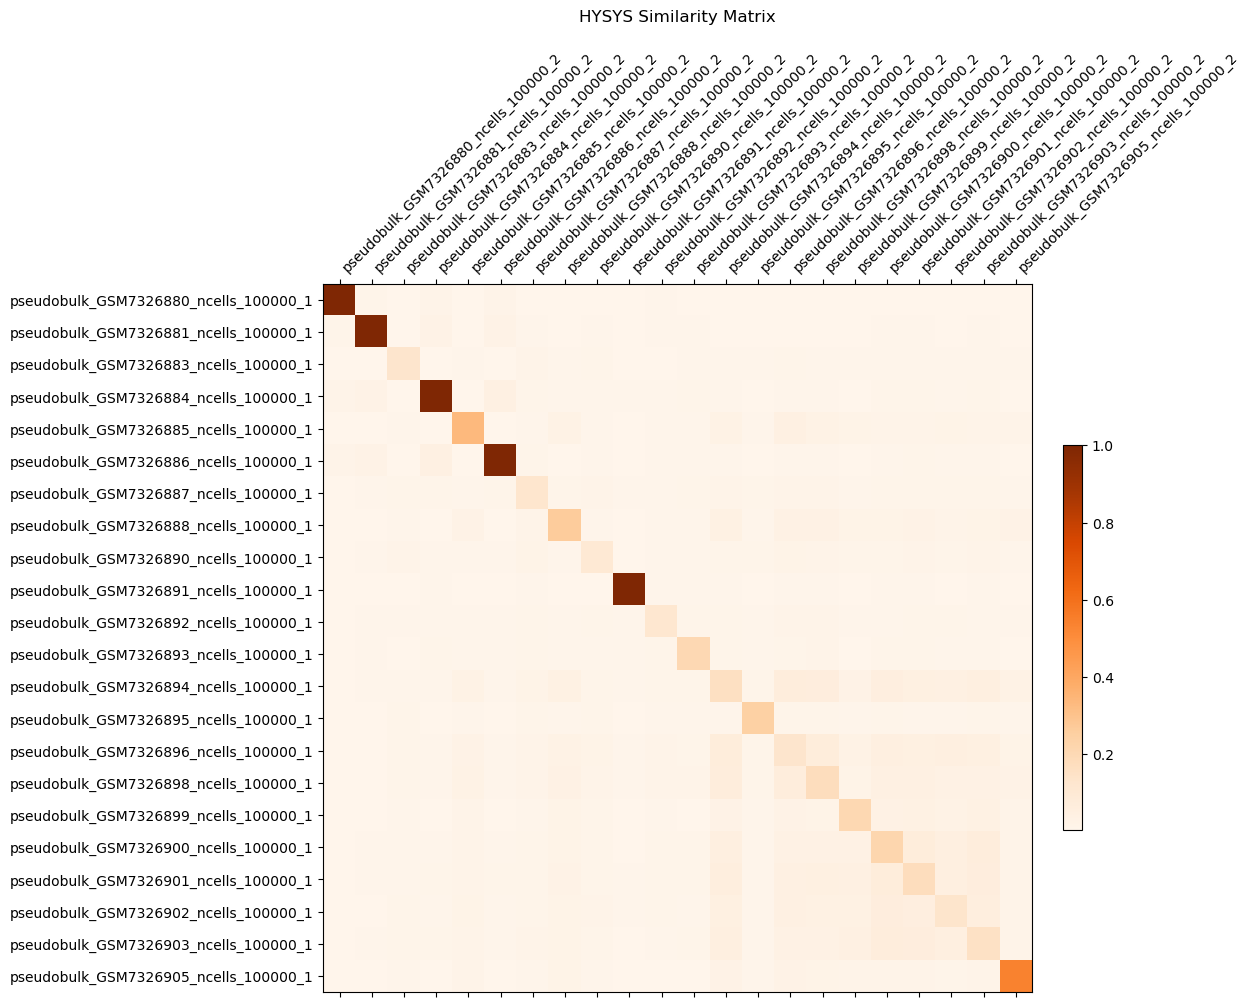

In [47]:
all_samples_matrix_viz(
    hysys_matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=False
)

## Detailed accuracy metrics

In [109]:
sample_matches_df.head()

match
sample1                               sample2                                     
pseudobulk_GSM7326880_ncells_100000_1 pseudobulk_GSM7326880_ncells_100000_2      1
                                      pseudobulk_GSM7326880_ncells_100000_3      1
                                      pseudobulk_GSM7326881_ncells_100000_1      1
                                      pseudobulk_GSM7326881_ncells_100000_2      1
                                      pseudobulk_GSM7326881_ncells_100000_3      1

In [110]:
# Get all pairs where one sample ends with _1 and the other ends with _2
# Since itertools.combinations ensures consistent ordering, we need to check both possibilities
def has_one_suffix_each(sample1, sample2, suffix1, suffix2):
    """Check if one sample has suffix1 and the other has suffix2 (order doesn't matter)"""
    return ((sample1.endswith(suffix1) and sample2.endswith(suffix2)) or
            (sample1.endswith(suffix2) and sample2.endswith(suffix1)))

# Filter to get _1 vs _2 pairs (avoiding double counting)
mask = sample_matches_df.index.to_series().apply(
    lambda x: has_one_suffix_each(x[0], x[1], pseudobulk_1, pseudobulk_2)
)

hysys_pseudobulk_pairs = sample_matches_df[mask]

print(f"Found {len(hysys_pseudobulk_pairs)} unique pairs comparing _1 vs _2 pseudobulk samples")
print(f"Expected: 22 × 22 = 484 pairs")

Found 484 unique pairs comparing _1 vs _2 pseudobulk samples
Expected: 22 × 22 = 484 pairs


In [111]:
# Reorder pairs so that _1 samples are always in sample1 position and _2 samples in sample2 position
reordered_pairs = []

for (s1, s2), row in hysys_pseudobulk_pairs.iterrows():
    if s1.endswith('_1') and s2.endswith('_2'):
        # Already in correct order
        reordered_pairs.append({'sample1': s1, 'sample2': s2, 'match': row['match']})
    elif s1.endswith('_2') and s2.endswith('_1'):
        # Swap the order
        reordered_pairs.append({'sample1': s2, 'sample2': s1, 'match': row['match']})

# Create new DataFrame with consistent ordering
hysys_pseudobulk_pairs_reordered = pd.DataFrame(reordered_pairs)
hysys_pseudobulk_pairs_reordered = hysys_pseudobulk_pairs_reordered.set_index(['sample1', 'sample2'])

In [131]:
hysys_pseudobulk_pairs_reordered.head()

match
sample1                               sample2                                     
pseudobulk_GSM7326880_ncells_100000_1 pseudobulk_GSM7326880_ncells_100000_2      1
                                      pseudobulk_GSM7326881_ncells_100000_2      1
                                      pseudobulk_GSM7326883_ncells_100000_2      1
                                      pseudobulk_GSM7326884_ncells_100000_2      1
                                      pseudobulk_GSM7326885_ncells_100000_2      1

In [125]:
# Create true_matches matrix for submatrix 
# Matches on the diagonal (1), the rest non-matches (0)
true_matches = pd.DataFrame(
    np.identity(len(hysys_matrix_filtered)),
    index=pd.Index(sorted(set(hysys_pseudobulk_pairs_reordered.index.get_level_values(0))), name="pseudobulk_1"), 
    columns=pd.Index(sorted(set(hysys_pseudobulk_pairs_reordered.index.get_level_values(1))), name="pseudobulk_2"),
    )

In [127]:
# Melt matrix into long form 
true_matches_long = true_matches.stack().rename("match").reset_index().set_index(["pseudobulk_1", "pseudobulk_2"])

In [130]:
# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(true_matches_long, hysys_pseudobulk_pairs_reordered).ravel().tolist()

In [132]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 0.05
Balanced accuracy = 0.50
Precision = 0.05
Recall = 1.00
F1 = 0.09
